In [1]:
import sys
sys.path.insert(0, 'utils')

import xarray as xr
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.shapereader
from scipy import stats
import re
import dataloader

os.makedirs("figures/ACC drivers Raw", exist_ok=True)

## Load GEFS data and build anomaly time series (Raw ACC)

In [2]:
# Load GEFS wk3-4 forecast (x) and IMD obs (y) — same pipeline as ACCs.ipynb
# Use the full GEFSv12 hindcast period (1989-2018) to match ELR/U-Net's Full Period evaluation.
domain = [67, 98, 7, 38]
years  = (1989, 2018)
season = "May-Sep"

x_week34, y_week34 = dataloader.get_data(
    years=years, download=False, week="wk3-4", obs="IMD",
    domain=domain, season=season, model="GEFS", regrid=1
)

# GEFS hindcast climatology (for forecast anomalies)
gefs_climo = xr.open_dataset('download/gefs_climo.nc')
gefs_climo['S'] = pd.to_datetime(gefs_climo['S'])
gefs_climo['L'] = gefs_climo['L'] / np.timedelta64(1, 'D')

# Build anomalies per ISO week (forecast: lead-time climo; obs: weekly mean)
week_to_lead = {"wk3-4": (16.5, 28.5)}
x = x_week34.mean('M')
y = y_week34

x_anom_list, y_anom_list = [], []
for week_i in set(x['T'].dt.isocalendar().week.values):
    x_week_i = x.where(x['T'].dt.isocalendar().week == week_i, drop=True)
    y_week_i = y.where(y['T'].dt.isocalendar().week == week_i, drop=True)

    first_date = pd.Timestamp(x_week_i['S'].values[0])
    m, d = first_date.month, first_date.day

    x_week_climo = gefs_climo.sel(
        S=(gefs_climo['S'].dt.month == m) & (gefs_climo['S'].dt.day == d)
    ).sel(L=slice(week_to_lead["wk3-4"][0], week_to_lead["wk3-4"][1])).mean('L').mean('S')
    x_week_climo = x_week_climo.rename({'pr': 'prcp'})

    y_week_anom = y_week_i - y_week_i.mean('T')
    x_week_anom = x_week_i - x_week_climo

    x_anom_list.append(x_week_anom)
    y_anom_list.append(y_week_anom)

x_anom = xr.merge(x_anom_list)['prcp'].sortby('T')
y_anom = xr.merge(y_anom_list)['prcp'].sortby('T')

real_X = x_anom.X
real_Y = x_anom.Y

# Land mask: UNION of obs-NaN and ELR-predictions-NaN, so Raw/ELR/U-Net cover identical grid cells.
land_mask_obs = y_anom.isnull().all(dim='T')
preds_elr_ref = xr.open_dataarray('outputs/Full Period/GEFS_IMD/ELR_predictions_wk3-4.nc')
land_mask_elr = preds_elr_ref.isel(bootstrap=0, category=0).isnull().all(dim='T').assign_coords(X=real_X, Y=real_Y)
land_mask = (land_mask_obs | land_mask_elr).assign_coords(X=real_X, Y=real_Y)

# Expose obs_oheM = y_anom so downstream cells (MJO/ENSO date selection) work unchanged
obs_oheM = y_anom

print("x_anom shape:", x_anom.shape)
print("y_anom shape:", y_anom.shape)
print("T range:", str(pd.Timestamp(x_anom['T'].values[0]))[:10],
      "to", str(pd.Timestamp(x_anom['T'].values[-1]))[:10])
print(f"land_mask True fraction: {float(land_mask.mean()):.4f}")

C:\Users\emile\AppData\Local\Temp\ipykernel_7808\3872578260.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  gefs_climo = xr.open_dataset('download/gefs_climo.nc')


x_anom shape: (660, 32, 32)
y_anom shape: (660, 32, 32)
T range: 1989-05-25 to 2018-10-18
land_mask True fraction: 0.7070


## Anomaly correlation coefficient (ACC)

$$\text{ACC}(\mathbf{x}) = \text{corr}_t(x'_t, y'_t)$$

ACC is signed (in [-1, 1]) and so doesn't suffer from the small-sample inflation of $1 - \sqrt{1 - \text{ACC}^2}$, which is bounded below by 0.

In [3]:
def acc(x_an, y_an, dim='T'):
    """ACC = correlation between forecast and obs anomalies, land-masked."""
    return xr.corr(x_an, y_an, dim=dim).where(~land_mask).assign_coords(X=real_X, Y=real_Y)

# Reuse rpss-named binding so downstream cells (overall_mean refs, deviation maps) keep working
rpss = acc(x_anom, y_anom)

print("Raw ACC range:", float(rpss.min().values), "to", float(rpss.max().values))
print("Raw ACC spatial mean:", float(rpss.mean().values))

Raw ACC range: -0.09403632405659262 to 0.30746014185079945
Raw ACC spatial mean: 0.14240351129410306


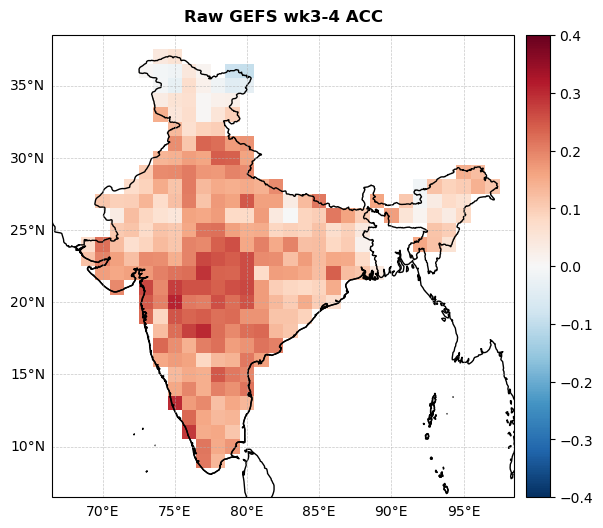

In [4]:
def plot_map(da, title="", cmap="RdBu_r", vmin=-0.4, vmax=0.4):
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
    im = da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
                 vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels = False; gl.right_labels = False
    plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.05)
    plt.show()

plot_map(rpss, title="Raw GEFS wk3-4 ACC")

# MJO

In [5]:
mjo = pd.read_csv(
    "download/mjo.txt", skiprows=2, sep=r'\s+', header=None,
    names=["year","month","day","RMM1","RMM2","phase","amplitude","method","extra"],
    na_values=[1e35, 999]
).drop(columns="extra", errors="ignore")
mjo["date"] = pd.to_datetime(dict(year=mjo.year, month=mjo.month, day=mjo.day), errors="coerce")
mjo = mjo[(mjo['date'] >= '1980-01-01') & (mjo['date'] <= '2025-12-31')].set_index('date')

df_mjo_roll = mjo[['RMM1','RMM2']].rolling(window=15, center=True, min_periods=1).mean()
mjo_xr = df_mjo_roll.to_xarray()

rpss_dates = pd.to_datetime(obs_oheM['T'].values)
rmm1 = mjo_xr['RMM1'].sel(date=rpss_dates, method='nearest').values
rmm2 = mjo_xr['RMM2'].sel(date=rpss_dates, method='nearest').values
phase_num = (((np.arctan2(rmm2, rmm1) + 2*np.pi) % (2*np.pi)) // (np.pi/4) + 1).astype(int)
phase_da  = xr.DataArray(phase_num, dims=('T',), coords={'T': obs_oheM['T']})
print("Phase counts:", {int(p): int((phase_da==p).sum()) for p in range(1,9)})

Phase counts: {1: 79, 2: 81, 3: 57, 4: 74, 5: 118, 6: 106, 7: 72, 8: 73}


## Raw ACC per MJO phase

In [6]:
rpss_mjo = {}
for phase in range(1, 9):
    mask_t = (phase_da == phase).values
    if mask_t.sum() < 3:
        continue
    rpss_mjo[phase] = acc(x_anom.isel(T=mask_t), y_anom.isel(T=mask_t))

print("Phases computed:", list(rpss_mjo.keys()))
for ph, r in rpss_mjo.items():
    print(f"  P{ph}: spatial mean ACC = {float(r.mean()):+.4f} (n={int((phase_da == ph).sum())})")

Phases computed: [1, 2, 3, 4, 5, 6, 7, 8]
  P1: spatial mean ACC = +0.1162 (n=79)
  P2: spatial mean ACC = +0.1239 (n=81)
  P3: spatial mean ACC = +0.1662 (n=57)
  P4: spatial mean ACC = +0.1610 (n=74)
  P5: spatial mean ACC = +0.1234 (n=118)
  P6: spatial mean ACC = +0.1027 (n=106)
  P7: spatial mean ACC = +0.1273 (n=72)
  P8: spatial mean ACC = +0.1369 (n=73)


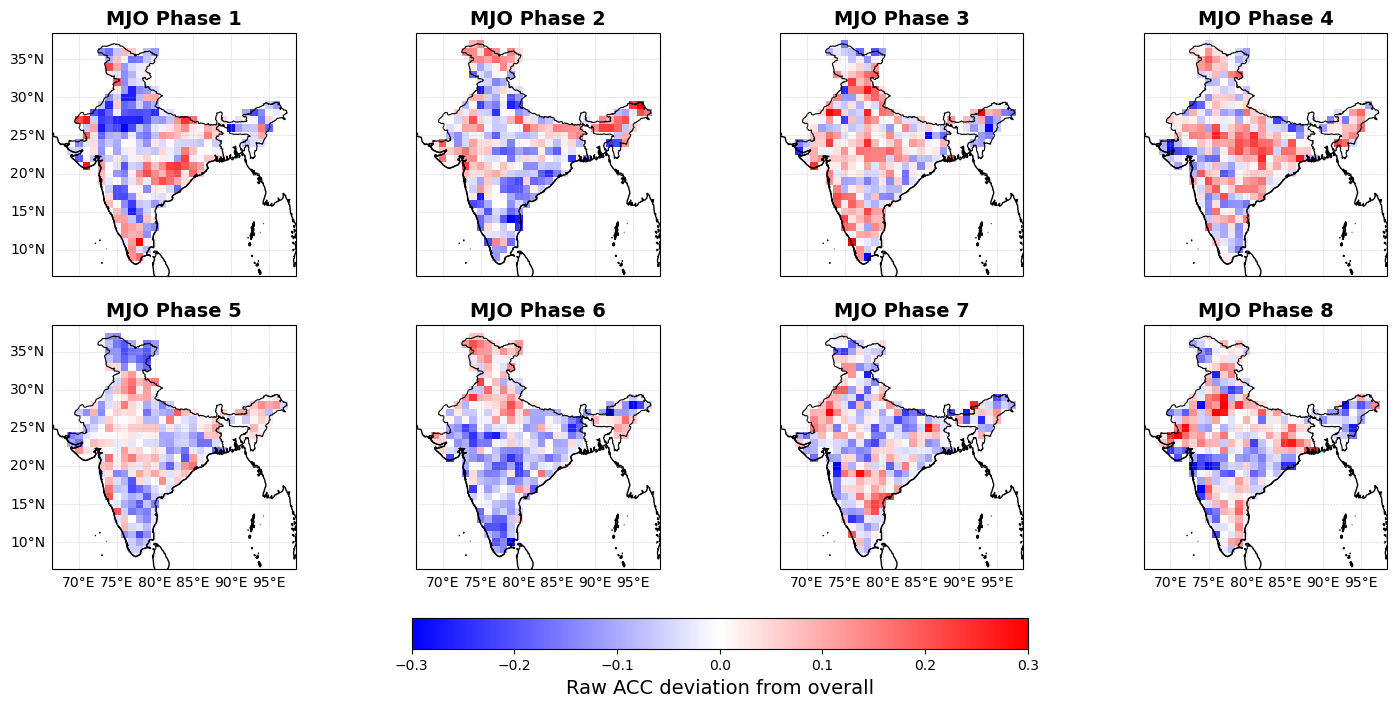

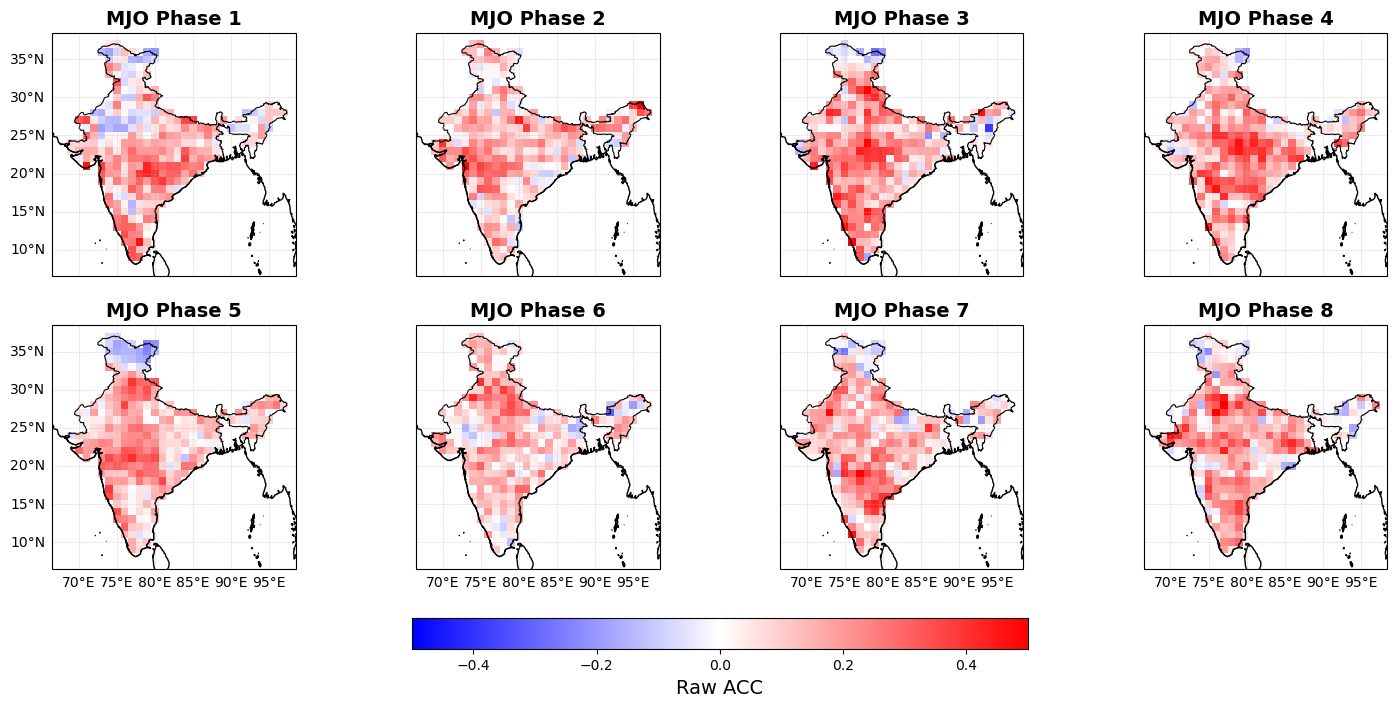

In [7]:
def plot_mjo_phases(rpss_dict, demean=True, rpss_ref=None,
                   vmin=-0.3, vmax=0.3, cmap='bwr', fname=None):
    if rpss_ref is None:
        rpss_ref = rpss
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    axes = axes.flatten(); mappable = None

    for i, phase in enumerate(range(1,9)):
        ax  = axes[i]
        val = rpss_dict[phase]
        if demean:
            val = val - rpss_ref
        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        if mappable is None: mappable = im
        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i % 4 != 0: gl.left_labels = False
        if i < 4:      gl.bottom_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
    cbar.set_label("Raw ACC deviation from overall" if demean else "Raw ACC", fontsize=14)
    if fname:
        plt.savefig(f"figures/ACC drivers Raw/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_mjo_phases(rpss_mjo, demean=True,  fname="ACC_Raw_MJO_deviation.pdf")
plot_mjo_phases(rpss_mjo, demean=False, vmin=-0.5, vmax=0.5, fname="ACC_Raw_MJO_plain.pdf")

## MJO composite maps with stippling (phase vs all, p < 0.10)

Significance via bootstrap-resampling: for each grid cell, draw N_phase dates at random, compute ACC, repeat 500×, and flag cells where the observed phase ACC deviates from the null mean by more than 90% of bootstrap draws.

C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


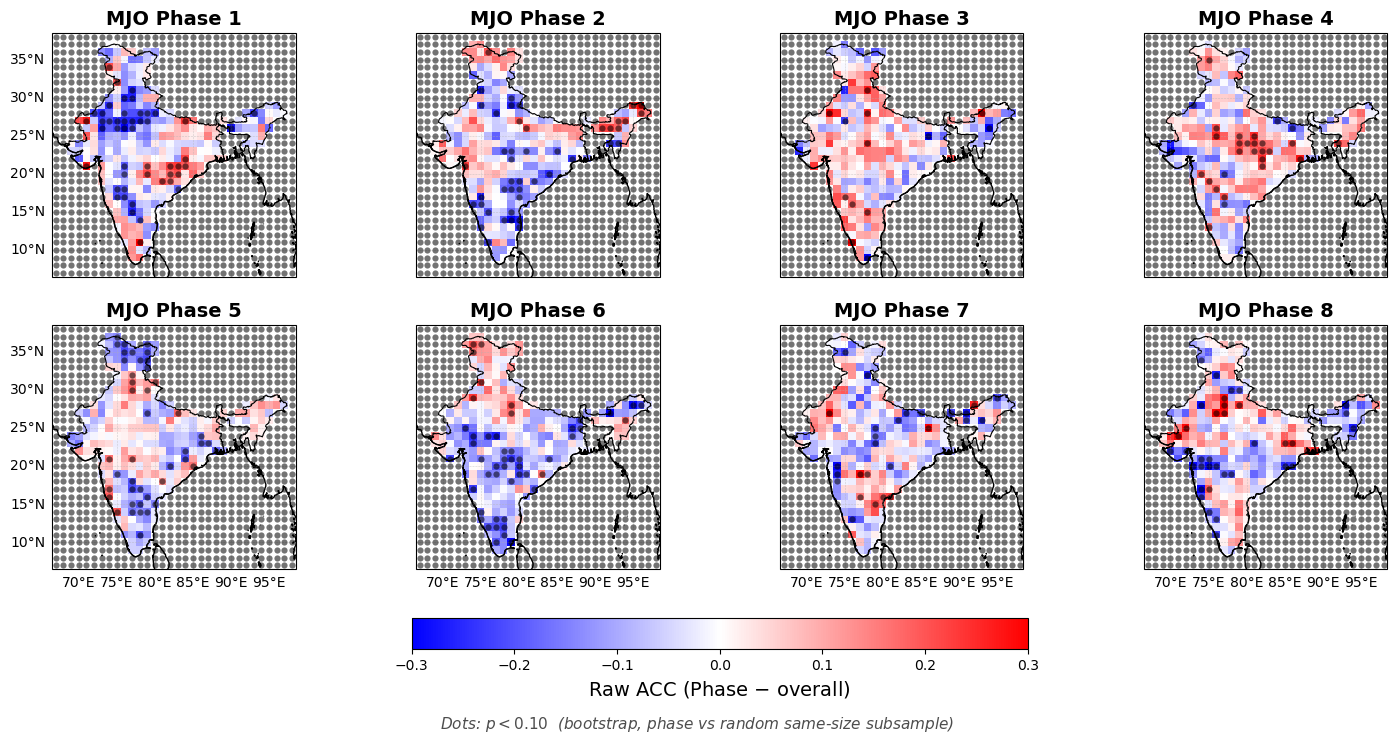

In [8]:
# Bootstrap-resampled null distribution of phase-conditional ACC
N_BOOT = 500
rng = np.random.default_rng(0)
T_total = x_anom.sizes['T']

def bootstrap_pval(acc_obs, n_phase, n_boot=N_BOOT):
    """Two-sided p-value via random same-size subsamples from all T dates."""
    sims = np.empty((n_boot,) + acc_obs.shape, dtype=float)
    for k in range(n_boot):
        idx = rng.choice(T_total, size=n_phase, replace=False)
        sims[k] = xr.corr(x_anom.isel(T=idx), y_anom.isel(T=idx), dim='T').values
    sim_mean = np.nanmean(sims, axis=0)
    obs_dev  = np.abs(acc_obs.values - sim_mean)
    sim_dev  = np.abs(sims - sim_mean)
    return (sim_dev >= obs_dev).mean(axis=0)

mjo_pval = {}
for phase in range(1, 9):
    n_ph = int((phase_da == phase).sum())
    if n_ph < 3:
        continue
    pv = bootstrap_pval(rpss_mjo[phase], n_ph)
    mjo_pval[phase] = xr.DataArray(pv, dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X})

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten(); mappable = None

for i, phase in enumerate(range(1,9)):
    ax   = axes[i]
    diff = rpss_mjo[phase] - rpss
    im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                     cmap='bwr', vmin=-0.3, vmax=0.3, add_colorbar=False)
    if mappable is None: mappable = im

    pv  = mjo_pval[phase]
    sig = (pv < 0.10).values
    lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
    ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
               linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 4:      gl.bottom_labels = False
    gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Raw ACC (Phase $-$ overall)", fontsize=14)
fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (bootstrap, phase vs random same-size subsample)",
         ha="center", fontsize=11, style="italic", color="0.3")
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_composite_sig.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ENSO

In [9]:
records = []
pattern = re.compile(r"[+-]?\d+\.\d+")
with open("download/sst_weekly.txt") as f:
    for line in f:
        if re.match(r"\s*\d{2}[A-Z]{3}\d{4}", line):
            date = line.split()[0]
            nums = list(map(float, pattern.findall(line)))
            if len(nums) == 8:
                records.append([date] + nums)

cols = ["Week","Nino12_SST","Nino12_SSTA","Nino3_SST","Nino3_SSTA",
        "Nino34_SST","Nino34_SSTA","Nino4_SST","Nino4_SSTA"]
nino = pd.DataFrame(records, columns=cols)
nino["Week"] = pd.to_datetime(nino["Week"], format="%d%b%Y")
nino = nino.set_index("Week").rolling(window=2, center=True, min_periods=1).mean()
nino_xr = nino.to_xarray()

nino4_vals = nino_xr["Nino4_SSTA"].sel(Week=rpss_dates, method="nearest").values

enso4_da = xr.DataArray(xr.where(xr.DataArray(nino4_vals, dims='T') >=  0.5, 1,
                          xr.where(xr.DataArray(nino4_vals, dims='T') <= -0.5, -1, 0)).values,
                         dims=('T',), coords={'T': obs_oheM['T']})

print("ENSO4 counts:", {int(v): int((enso4_da==v).sum()) for v in [-1,0,1]})

ENSO4 counts: {-1: 135, 0: 443, 1: 82}


## Raw ACC per ENSO mode + composite stippling maps

In [10]:
def rpss_by_enso(mode_da):
    out = {}
    for mode in [-1, 0, 1]:
        mask_t = (mode_da == mode).values
        if mask_t.sum() < 3: continue
        out[mode] = acc(x_anom.isel(T=mask_t), y_anom.isel(T=mask_t))
    return out

rpss_enso4 = rpss_by_enso(enso4_da)
for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    print(f"  {lb}: spatial mean ACC = {float(rpss_enso4[mode].mean()):+.4f} (n={int((enso4_da==mode).sum())})")

  La Nina: spatial mean ACC = +0.0786 (n=135)
  Neutral: spatial mean ACC = +0.1627 (n=443)
  El Nino: spatial mean ACC = +0.1128 (n=82)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


C:\Users\emile\AppData\Local\Temp\ipykernel_7808\325084308.py:12: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(sims, axis=0)


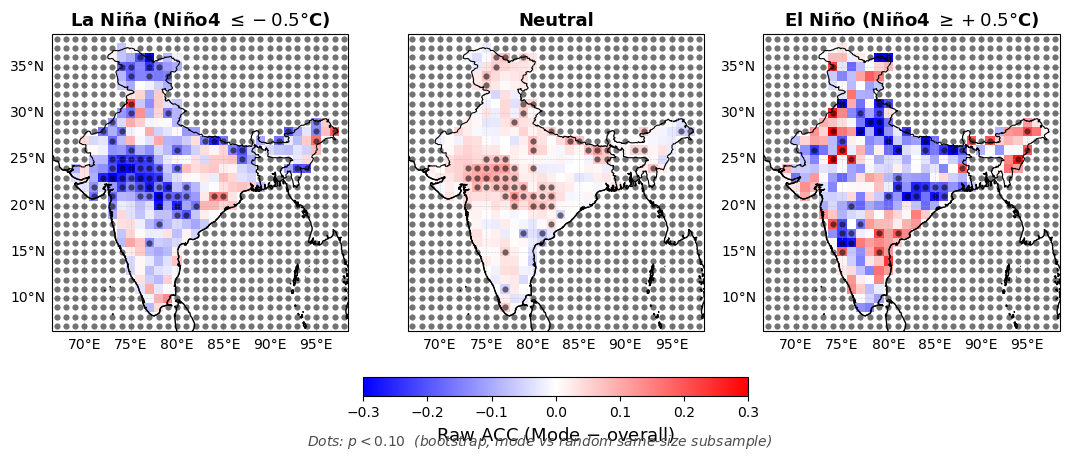

In [11]:
def plot_enso_sig(rpss_enso, mode_da, titles, fname, alpha=0.10):
    enso_pval = {}
    for mode in [-1, 0, 1]:
        n_m = int((mode_da == mode).sum())
        if n_m < 3: continue
        pv = bootstrap_pval(rpss_enso[mode], n_m)
        enso_pval[mode] = xr.DataArray(pv, dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X})

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13,5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax   = axes[i]
        diff = rpss_enso[mode] - rpss
        im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='bwr', vmin=-0.3, vmax=0.3, add_colorbar=False)
        if mappable is None: mappable = im

        pv  = enso_pval[mode]
        sig = (pv < alpha).values
        lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
        ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
                   linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12)
    cbar.set_label("Raw ACC (Mode $-$ overall)", fontsize=13)
    fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (bootstrap, mode vs random same-size subsample)",
             ha="center", fontsize=10, style="italic", color="0.3")
    plt.savefig(f"figures/ACC drivers Raw/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

nino4_titles = {-1: r"La Niña (Niño4 $\leq -0.5°$C)", 0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}

plot_enso_sig(rpss_enso4, enso4_da, nino4_titles, "ACC_Raw_ENSO4_composite_sig.pdf")

## Plain ACC per ENSO mode (Niño4)

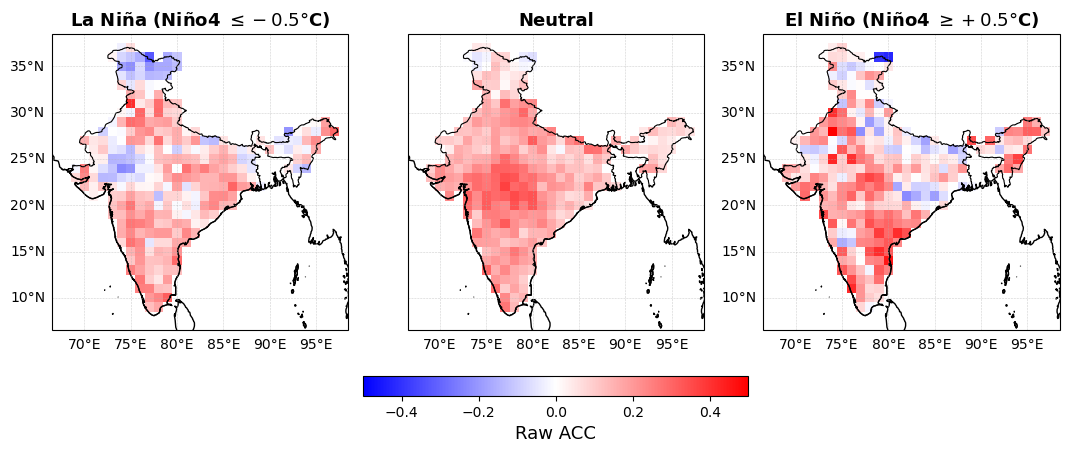

In [12]:
def plot_enso_plain(rpss_enso, titles, fname):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax  = axes[i]
        val = rpss_enso[mode]

        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap='bwr', vmin=-0.5, vmax=0.5, add_colorbar=False)
        if mappable is None:
            mappable = im

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)

        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size": 10}; gl.ylabel_style = {"size": 10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                        fraction=0.05, pad=0.12)
    cbar.set_label("Raw ACC", fontsize=13)
    plt.savefig(f"figures/ACC drivers Raw/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_enso_plain(rpss_enso4, nino4_titles, "ACC_Raw_ENSO4_plain.pdf")

## Box plots

C:\Users\emile\AppData\Local\Temp\ipykernel_7808\3377567511.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_enso, x="Category", y="ACC",
C:\Users\emile\AppData\Local\Temp\ipykernel_7808\3377567511.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mjo, x="Category", y="ACC",
C:\Users\emile\AppData\Local\Temp\ipykernel_7808\3377567511.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


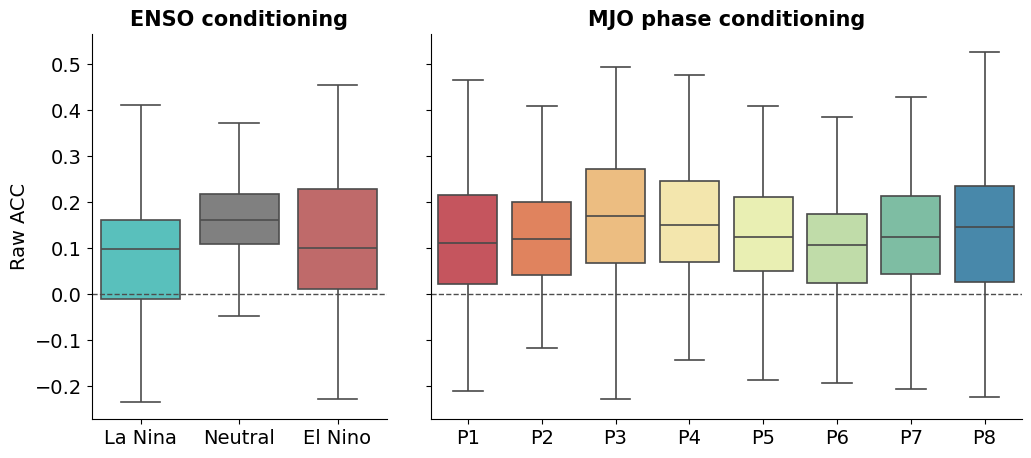

In [13]:
rows_mjo, rows_enso = [], []
for phase in range(1, 9):
    vals = rpss_mjo[phase].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_mjo.append({"Category": f"P{phase}", "ACC": v})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    vals = rpss_enso4[mode].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_enso.append({"Category": lb, "ACC": v})

df_mjo  = pd.DataFrame(rows_mjo)
df_enso = pd.DataFrame(rows_enso)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

sns.boxplot(data=df_enso, x="Category", y="ACC",
            order=["La Nina", "Neutral", "El Nino"],
            palette=['mediumturquoise', 'gray', 'indianred'],
            showfliers=False, ax=axes[0], linewidth=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("Raw ACC", fontsize=14)

sns.boxplot(data=df_mjo, x="Category", y="ACC",
            palette=sns.color_palette("Spectral", 8),
            showfliers=False, ax=axes[1], linewidth=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for ax in axes:
    ax.axhline(0, color="0.3", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", labelsize=14, rotation=0)
axes[0].tick_params(axis="y", labelsize=14)

sns.despine()
plt.tight_layout()
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_ENSO_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\emile\AppData\Local\Temp\ipykernel_7808\1762128976.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


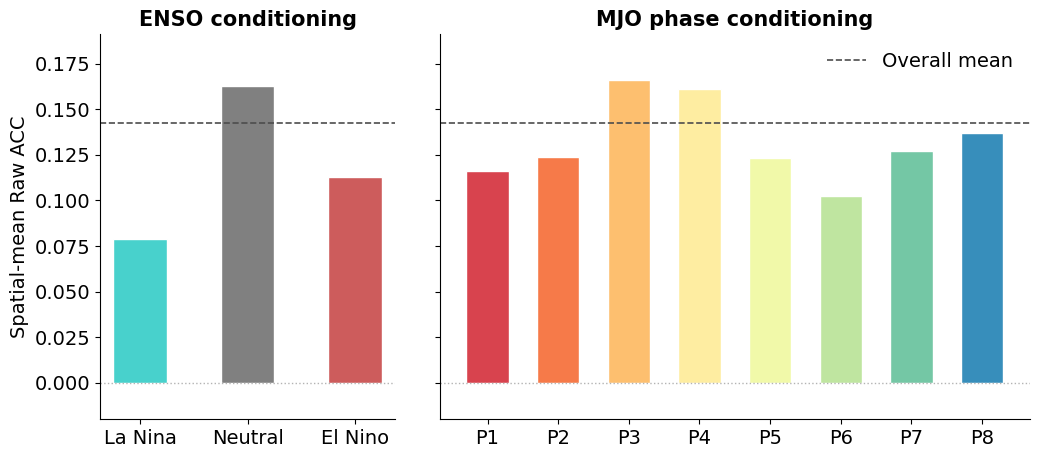

In [14]:
rows_mjo_sp, rows_enso_sp = [], []
for phase in range(1, 9):
    rows_mjo_sp.append({"Category": f"P{phase}", "ACC": float(rpss_mjo[phase].mean().values)})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    rows_enso_sp.append({"Category": lb, "ACC": float(rpss_enso4[mode].mean().values)})

df_mjo_sp  = pd.DataFrame(rows_mjo_sp)
df_enso_sp = pd.DataFrame(rows_enso_sp)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

axes[0].bar(enso_order, df_enso_sp["ACC"], color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean Raw ACC", fontsize=14)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=14)

axes[1].bar(df_mjo_sp["Category"], df_mjo_sp["ACC"], color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=14)
axes[1].legend(fontsize=14, frameon=False)

# Flexible y-range
all_vals = df_mjo_sp["ACC"].tolist() + df_enso_sp["ACC"].tolist() + [float(rpss.mean().values)]
ymin = min(0, min(all_vals)) - 0.02
ymax = max(all_vals) * 1.15
for ax in axes:
    ax.axhline(0, color='0.7', ls=':', lw=1)
    ax.set_ylim(ymin, ymax)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_ENSO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

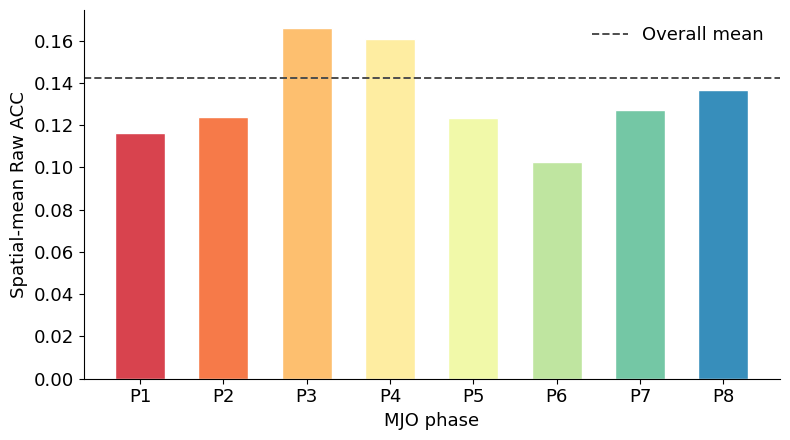

In [15]:
mjo_means    = [float(rpss_mjo[ph].mean().values) for ph in range(1, 9)]
overall_mean = float(rpss.mean().values)
mjo_colors   = sns.color_palette("Spectral", 8)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(1, 9), mjo_means, color=mjo_colors, edgecolor='white', width=0.6)
ax.axhline(overall_mean, color='0.3', ls='--', lw=1.4, label='Overall mean')
ax.set_xticks(range(1, 9))
ax.set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
ax.set_xlabel("MJO phase", fontsize=13)
ax.set_ylabel("Spatial-mean Raw ACC", fontsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.legend(fontsize=13, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\emile\AppData\Local\Temp\ipykernel_7808\3351693889.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


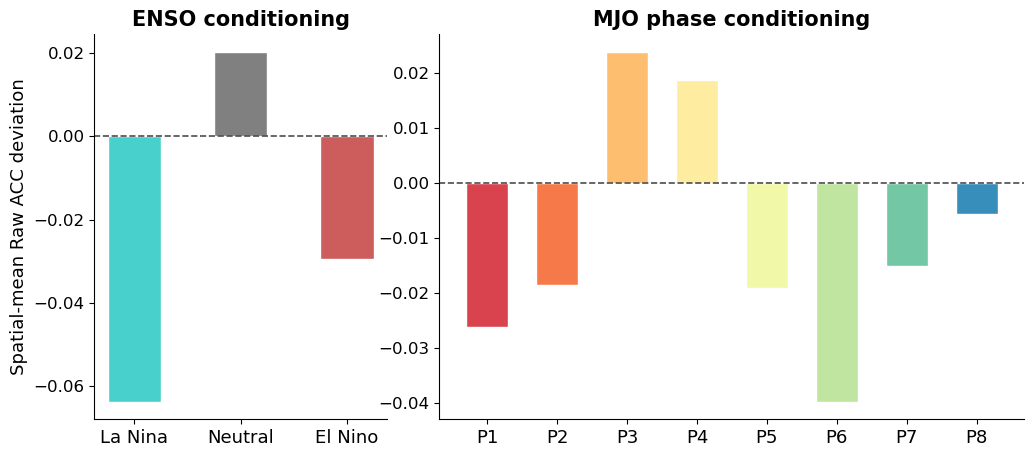

In [16]:
enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

enso_dev_means = {}
for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    dev = rpss_enso4[mode] - rpss
    enso_dev_means[lb] = float(dev.mean().values)

mjo_dev_means = []
for ph in range(1, 9):
    dev = rpss_mjo[ph] - rpss
    mjo_dev_means.append(float(dev.mean().values))

fig, axes = plt.subplots(ncols=2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.12})

axes[0].bar(enso_order, [enso_dev_means[lb] for lb in enso_order],
            color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(0, color='0.3', ls='--', lw=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean Raw ACC deviation", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=13)
axes[0].tick_params(axis="y", labelsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].bar(range(1, 9), mjo_dev_means, color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(0, color='0.3', ls='--', lw=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticks(range(1, 9))
axes[1].set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
axes[1].tick_params(axis="y", labelsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_ENSO_deviation_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Combined MJO phase × ENSO mode stratification

In [17]:
amplitude = np.sqrt(rmm1**2 + rmm2**2)
amplitude_da = xr.DataArray(amplitude, dims=('T',), coords={'T': obs_oheM['T']})

active_da = amplitude_da >= 1.0
print(f"Active MJO dates: {int(active_da.sum())} / {len(active_da)}")
print("Phase counts (active only):")
for ph in range(1, 9):
    n = int(((phase_da == ph) & active_da).sum())
    print(f"  Phase {ph}: {n}")

Active MJO dates: 269 / 660
Phase counts (active only):
  Phase 1: 36
  Phase 2: 30
  Phase 3: 24
  Phase 4: 33
  Phase 5: 54
  Phase 6: 51
  Phase 7: 19
  Phase 8: 22


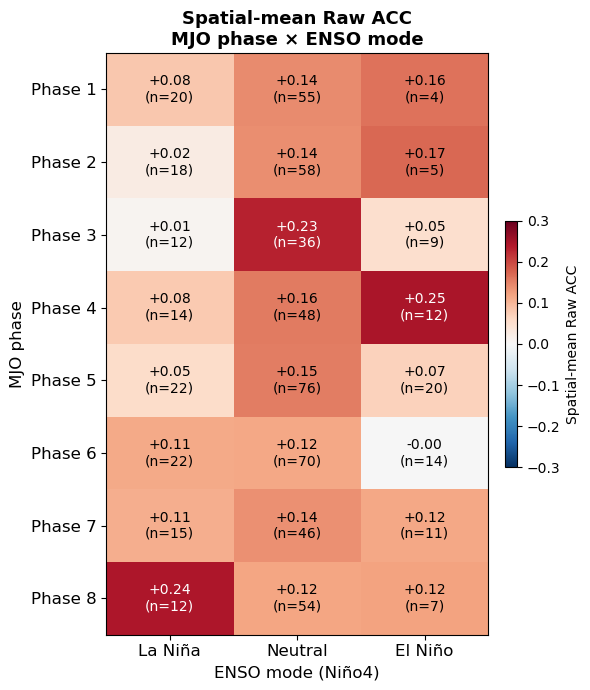

In [18]:
enso_modes  = [-1, 0, 1]
enso_labels = {-1: "La Niña", 0: "Neutral", 1: "El Niño"}
grid   = np.full((8, 3), np.nan)
n_grid = np.zeros((8, 3), dtype=int)

for pi, phase in enumerate(range(1, 9)):
    for ei, mode in enumerate(enso_modes):
        mask_t = ((phase_da == phase) & (enso4_da == mode)).values
        n = mask_t.sum()
        n_grid[pi, ei] = n
        if n < 3:
            continue
        acc_combo = acc(x_anom.isel(T=mask_t), y_anom.isel(T=mask_t))
        grid[pi, ei] = float(acc_combo.mean().values)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(grid, aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["La Niña", "Neutral", "El Niño"], fontsize=12)
ax.set_yticks(range(8))
ax.set_yticklabels([f"Phase {p}" for p in range(1, 9)], fontsize=12)
ax.set_xlabel("ENSO mode (Niño4)", fontsize=12)
ax.set_ylabel("MJO phase", fontsize=12)
ax.set_title("Spatial-mean Raw ACC\nMJO phase × ENSO mode", fontsize=13, fontweight="bold")

for pi in range(8):
    for ei in range(3):
        val = grid[pi, ei]
        n   = n_grid[pi, ei]
        txt = f"{val:+.2f}\n(n={n})" if not np.isnan(val) else f"n={n}"
        col = "white" if abs(val) > 0.2 else "black" if not np.isnan(val) else "0.5"
        ax.text(ei, pi, txt, ha='center', va='center', fontsize=10, color=col)

plt.colorbar(im, ax=ax, orientation='vertical', label='Spatial-mean Raw ACC', fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_ENSO_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

Sample sizes:
  El Niño + active MJO: n=40
  Neutral + active MJO: n=178
  La Niña + active MJO: n=51
  All active MJO: n=269
  All dates: n=660


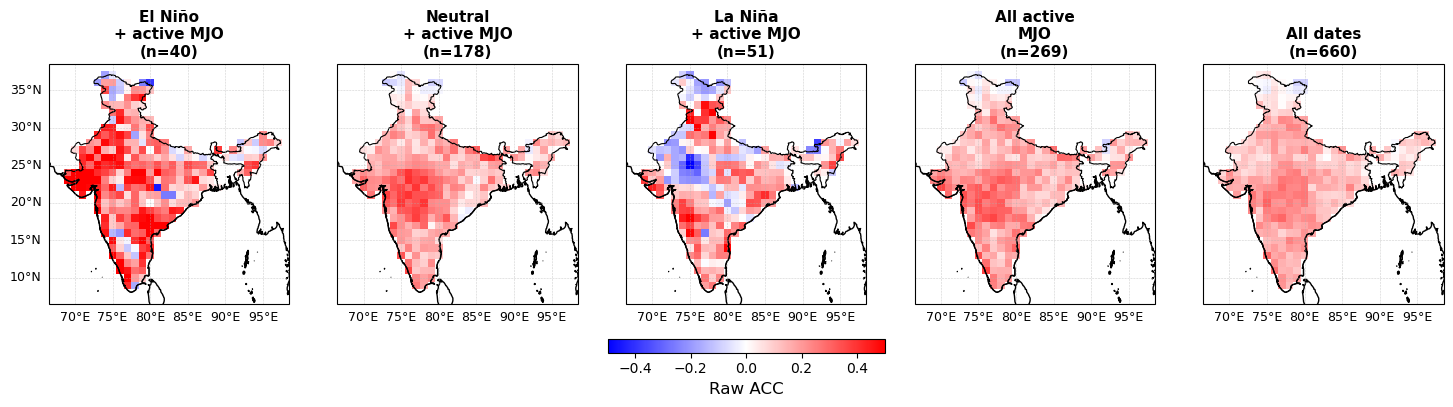

In [19]:
regimes = {
    "El Niño\n+ active MJO":  (enso4_da ==  1) & active_da,
    "Neutral\n+ active MJO":  (enso4_da ==  0) & active_da,
    "La Niña\n+ active MJO":  (enso4_da == -1) & active_da,
    "All active\nMJO":         active_da,
    "All dates":               xr.ones_like(enso4_da, dtype=bool),
}

regime_rpss = {}
for label, mask_da in regimes.items():
    mask_t = mask_da.values
    if mask_t.sum() < 3:
        regime_rpss[label] = np.nan
        continue
    regime_rpss[label] = acc(x_anom.isel(T=mask_t), y_anom.isel(T=mask_t))

print("Sample sizes:")
for label, mask_da in regimes.items():
    print(f"  {label.replace(chr(10),' ')}: n={int(mask_da.values.sum())}")

labels = list(regime_rpss.keys())
fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(18, 4.5),
                         subplot_kw={"projection": ccrs.PlateCarree()})
mappable = None

for i, label in enumerate(labels):
    ax  = axes[i]
    val = regime_rpss[label]
    n   = int(regimes[label].values.sum())

    if isinstance(val, float) and np.isnan(val):
        ax.set_visible(False)
        continue

    im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                  cmap='bwr', vmin=-0.5, vmax=0.5, add_colorbar=False)
    if mappable is None:
        mappable = im

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"{label}\n(n={n})", fontsize=11, fontweight="bold", pad=5)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i > 0: gl.left_labels = False
    gl.xlabel_style = {"size": 9}; gl.ylabel_style = {"size": 9}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.1)
cbar.set_label("Raw ACC", fontsize=12)
plt.savefig("figures/ACC drivers Raw/ACC_Raw_MJO_active_ENSO.pdf", dpi=300, bbox_inches="tight")
plt.show()